<a href="https://colab.research.google.com/github/Akanshajoshiiii/NLP_LAB/blob/main/4_Extrinsic_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👉 Ye PyTorch ki libraries hain

torch → tensors & loading/saving  

nn → neural network layers  

F → functions (activation etc.)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

embeddings1.shape == embeddings2.shape  
[embedding_dim, vocab_size] #final shape  


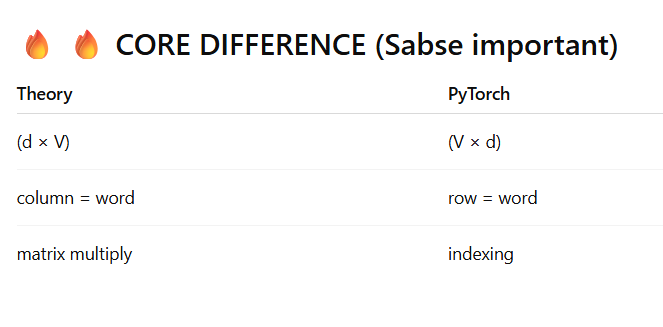

emb1=hidden layer (central word emb)  
emb2= output emb , context word

In [ ]:
embeddings1=torch.load('embeddings_hidden_10_epochs.pth')
#[vocab_size, embedding_dim] [50000, 100]
embeddings1=embeddings1.t() #transpose [100, 50000]
embeddings2=torch.load('embeddings_output_10_epochs.pth')
#[embedding_dim, vocab_size]
embeddings=(embeddings1+embeddings2)/2 #average

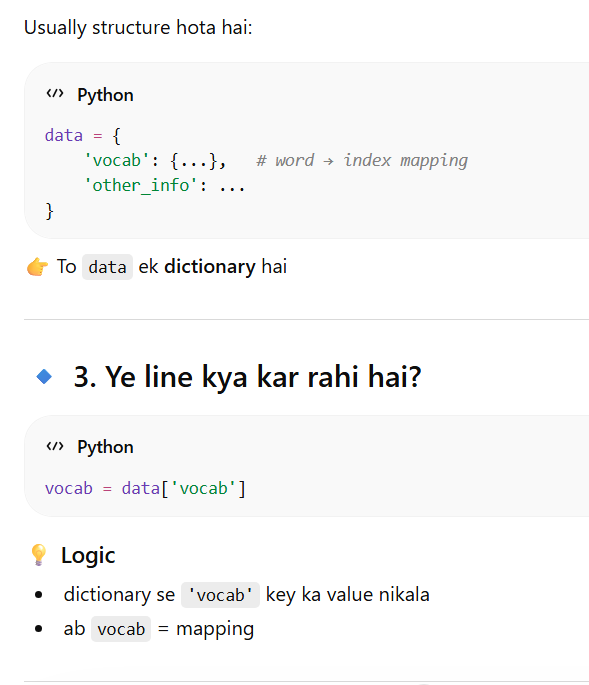

In [ ]:
data=torch.load('vocab_sgns.pth')
vocab=data['vocab']

In [ ]:
import pandas as pd
train_df=pd.read_csv('Train.csv')
test_df=pd.read_csv('Test.csv')

In [ ]:
train_df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [ ]:
import re
def preprocessing(text):
    text=text.lower()
    text=re.sub(r'[^a-zs\s]','',text) #jo bhi letter ya space nhi h remove
    return text.split()

In [ ]:
train_df['text']=train_df['text'].map(preprocessing)
test_df['text']=test_df['text'].map(preprocessing)

In [ ]:
vocab['PAD']=len(vocab) #padding k liye ek special token chahiye
#isliye last index use assign krdia

In [ ]:
len(vocab)

71291

In [ ]:
def encoding_padding(tokens,maxlen=256):
    encoded=[vocab[token] for token in tokens if token in vocab]
    encoded=encoded[:256] #len>256 ignore
    pad_len=maxlen-len(encoded)
    encoded+=[vocab['PAD']]*pad_len #list k end m pad fill krdia
    return encoded

In [ ]:
pad_vector = torch.zeros(1,100 , device=embeddings.device)
#ek dummy embedding vector bana rahe ho
#size = (1, embedding_dim) = (1, 100)

embeddings = torch.cat([embeddings, pad_vector], dim=0)
#rows ke along join karo concatenate



embeddings = (vocab_size, embedding_dim)
           = (71290, 100)

(1, 100)  
(71291, 100)

In [ ]:
class classification_dataset(torch.utils.data.Dataset):
    def __init__(self,texts,labels,vocab):
        self.texts=texts
        self.labels=labels
        self.vocab=vocab
    def __len__(self):
        return len(self.texts)
    def __getitem__(self,index):
        tokens=self.texts[index]
        encoded=encoding_padding(tokens)
        return torch.tensor(encoded),torch.tensor(self.labels[index],dtype=torch.float32)


In [ ]:
training_data=classification_dataset(train_df['text'].values,
                      train_df['label'].values,
                      vocab)
test_data=classification_dataset(test_df['text'].values,
                      test_df['label'].values,
                      vocab)

In [ ]:
training_data[0]

(tensor([  421,   930,    44,   485,  5214,    19, 11852,    15, 30381,   211,
           422, 44343,   218,  1179,  5531,  2513,   822, 30381,   143,  1179,
           230, 24103,    19,   557,  1179,  2513,   211, 11809,    29,    67,
         24508,    93,  5117,   259,   196, 11809,    29,    67,  3678, 12697,
          2954,    53,   482,   126,  5623,   404,   421,  1017,   422,  1915,
            29,   383,    15,  3512,  5048,   118,   357,  2286,     3,  8365,
             5,    73,   421,  2510,     2,     3,  1871,   125,  7209, 12049,
            15,   408,   681,   288,   147,    15,  3871, 14377,    89,    33,
            39,   348,  5996,   133,    15,  5676,  3476,     5,    15, 30381,
            10,  6872, 50585,   196,  3812,  4305,    25,  4264, 27355,     5,
            15,  1881, 16267, 13325,    19,   208,  5303,  1491,    66,  1632,
            26,   208,  6399,  8829,   208,  3386,   147,  2452,  8332,     3,
          9400,     5,  2716, 13016, 24419,     3, 3

In [ ]:
train_loader=torch.utils.data.DataLoader(training_data,batch_size=64,shuffle=True)
test_loader=torch.utils.data.DataLoader(test_data,batch_size=64,shuffle=True)

FINAL SHAPE

👉 rows = kitne sentences = 64  

👉 columns = har sentence ki length = 256  


x_batch = (64, 256)  
y_batch = [1,0,1,...]  → (64,)

In [ ]:
len(train_loader)

625

In [ ]:
class IMDBclassifier(nn.Module):
    def __init__(self,pretrained_embeddings):
        super(IMDBclassifier,self).__init__()
        vocab_size,output_dim=pretrained_embeddings.shape
        self.embed=nn.Embedding.from_pretrained(pretrained_embeddings,freeze=False)
        self.pool=nn.AdaptiveAvgPool1d(1)
        self.output_layer=nn.Linear(output_dim,1)
    def forward(self,input):
        x=self.embed(input).permute(0,2,1) #earlier- (64,256,100)
        x=self.pool(x).squeeze(2)

        x=self.output_layer(x)
        return x

(64,256)  
↓ embedding  
(64,256,100)  
↓ permute  
(64,100,256)  
↓ pooling  
(64,100,1)  
↓ squeeze  
(64,100)  
↓ linear
(64,1)

x = self.pool(x)

👉 shape:

(64,100,1)

👉 matlab:

256 words → average → 1 value

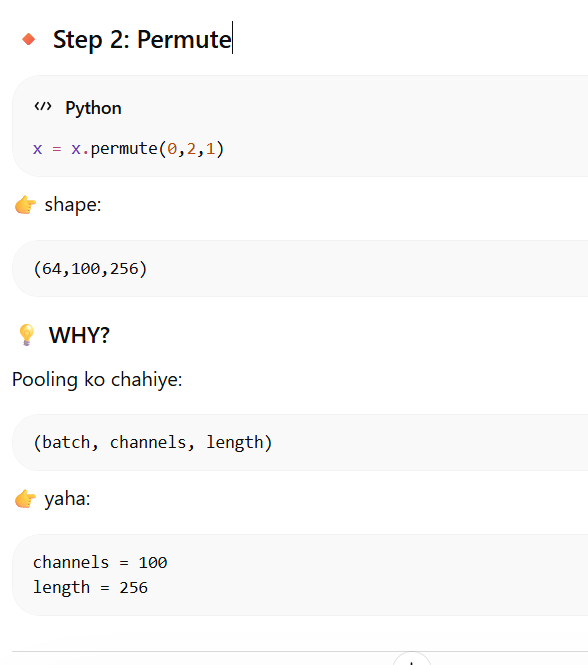

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
model=IMDBclassifier(embeddings).to(device)

In [ ]:
optimizer=torch.optim.Adam(model.parameters())
loss_fn=nn.BCEWithLogitsLoss() #binary classification or sigmoid directly lga deta h

In [ ]:
def batch_accuracy(y_pred,y_true):
    pred_labels=(y_pred>0.5).float()
    return (pred_labels==y_true).sum().item()/len(y_pred)

In [ ]:
from tqdm import tqdm
epochs=10
for epoch in range(epochs):
    loss=0
    accuracy=0
    model.train()
    loop=tqdm(train_loader,desc=f'Epoch {epoch+1}/{epochs}',leave=True)
    for (x_batch,y_batch) in loop:
        optimizer.zero_grad()
        x_batch,y_batch=x_batch.to(device),y_batch.to(device)
        #model output → (64,1)
        #squeeze → (64,)
        y_pred=model(x_batch).squeeze()
        batch_loss=loss_fn(y_pred,y_batch)
        batch_loss.backward()
        optimizer.step()
        loop.set_postfix(loss=batch_loss.item())
        loss+=batch_loss.item()
        accuracy+=batch_accuracy(y_pred,y_batch)
    print(f'Training accuracy over epoch {epoch+1} is {accuracy/len(train_loader)} and loss is {loss/len(train_loader)}')


Epoch 1/10: 100%|██████████| 625/625 [00:03<00:00, 188.88it/s, loss=0.134] 


Training accuracy over epoch 1 is 0.9557 and loss is 0.12182008600831032


Epoch 2/10: 100%|██████████| 625/625 [00:03<00:00, 189.45it/s, loss=0.105] 


Training accuracy over epoch 2 is 0.9606 and loss is 0.11118489610552788


Epoch 3/10: 100%|██████████| 625/625 [00:03<00:00, 188.08it/s, loss=0.0545]


...

Epoch 4/10: 100%|██████████| 625/625 [00:03<00:00, 178.64it/s, loss=0.116] 


Training accuracy over epoch 4 is 0.968675 and loss is 0.09266367057561875


Epoch 5/10: 100%|██████████| 625/625 [00:03<00:00, 184.61it/s, loss=0.091] 


Training accuracy over epoch 5 is 0.97195 and loss is 0.08463148467838764


Epoch 6/10:  78%|███████▊  | 487/625 [00:02<00:00, 189.34it/s, loss=0.104] 

x_batch → model → y_pred  
↓
loss calculate  
↓
backward (gradients)  
↓
optimizer.step (update)